The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


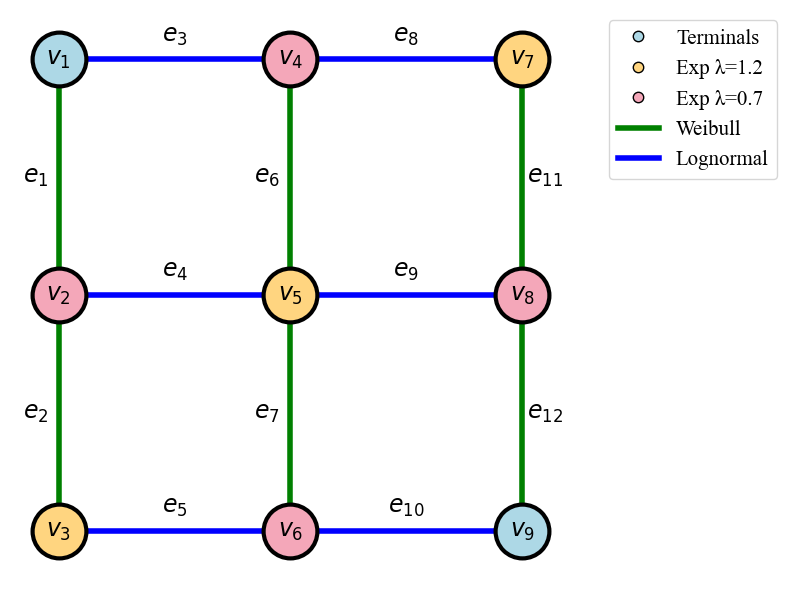

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

G = nx.Graph()
edges = [(1, 2), (2, 3), (1, 4), (2, 5), (3, 6), (4, 5),
         (5, 6), (4, 7), (5, 8), (6, 9), (7, 8), (8, 9)]
G.add_edges_from(edges)

Terminals = [1, 9]               
Exp_lambda12 = [3, 5, 7]          
Exp_lambda08 = [2, 4, 6, 8]       

weibull_edges = [1, 2, 6, 7, 11, 12]
lognorm_edges = [3, 4, 5, 8, 9, 10]

for i, edge in enumerate(edges, start=1):
    if i in weibull_edges:
        G[edge[0]][edge[1]]['type'] = 'Weibull'
    elif i in lognorm_edges:
        G[edge[0]][edge[1]]['type'] = 'Lognormal'

fixed_pos = {
    1: (0, 0), 2: (0, -1), 3: (0, -2),
    4: (1, 0), 5: (1, -1), 6: (1, -2),
    7: (2, 0), 8: (2, -1), 9: (2, -2)
}

edge_label_pos = {
    (1, 2): (-0.1, -0.5),
    (2, 3): (-0.1, -1.5),
    (1, 4): (0.5, 0.1),
    (2, 5): (0.5, -0.9),
    (3, 6): (0.5, -1.9),
    (4, 5): (0.9, -0.5),
    (5, 6): (0.9, -1.5),
    (4, 7): (1.5, 0.1),
    (5, 8): (1.5, -0.9),
    (6, 9): (1.5, -1.9),
    (7, 8): (2.1, -0.5),
    (8, 9): (2.1, -1.5),
}

plt.figure(figsize=(8, 6))
plt.axis('off')

a = 1500
nx.draw_networkx_nodes(G, fixed_pos, nodelist=Terminals,
                       node_color="lightblue", node_size=a,
                       edgecolors="black", linewidths=3, label="Terminals")
nx.draw_networkx_nodes(G, fixed_pos, nodelist=Exp_lambda12,
                       node_color="#FFD580", node_size=a,
                       edgecolors="black", linewidths=3, label="Exp λ=1.2")
nx.draw_networkx_nodes(G, fixed_pos, nodelist=Exp_lambda08,
                       node_color="#F4A7B9", node_size=a,
                       edgecolors="black", linewidths=3, label="Exp λ=0.7")

edge_colors = {'Weibull': 'green', 'Lognormal': 'blue'}
for etype, color in edge_colors.items():
    selected_edges = [(u, v) for u, v, d in G.edges(data=True) if d['type'] == etype]
    nx.draw_networkx_edges(G, fixed_pos, edgelist=selected_edges,
                           edge_color=color, width=4)

node_labels = {node: f'${{v_{{{node}}}}}$' for node in G.nodes()}
nx.draw_networkx_labels(G, fixed_pos, labels=node_labels,
                        font_size=17, font_weight='bold', font_family='serif')

for i, (u, v) in enumerate(edges, start=1):
    label = f'$e_{{{i}}}$'
    x, y = edge_label_pos[(u, v)] if (u, v) in edge_label_pos else edge_label_pos[(v, u)]
    plt.text(x, y, label, fontsize=17, color='black',
             ha='center', va='center')

handles = [
    plt.Line2D([0], [0], marker='o', color='w', label='Terminals',
               markerfacecolor='lightblue', markersize=15, markeredgecolor='black'),
    plt.Line2D([0], [0], marker='o', color='w', label='Exp λ=1.2',
               markerfacecolor='#FFD580', markersize=15, markeredgecolor='black'),
    plt.Line2D([0], [0], marker='o', color='w', label='Exp λ=0.7',
               markerfacecolor='#F4A7B9', markersize=15, markeredgecolor='black'),
    plt.Line2D([0], [0], color='green', lw=4, label='Weibull'),
    plt.Line2D([0], [0], color='blue', lw=4, label='Lognormal')
]

plt.legend(handles=handles, scatterpoints=1, markerscale=0.5,
           fontsize='large', bbox_to_anchor=(1.05, 1), loc='upper left',
           prop={'family': 'Times New Roman', 'size':15})

plt.tight_layout()
plt.savefig('1016mixed original network.png', bbox_inches='tight')
plt.show()




The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


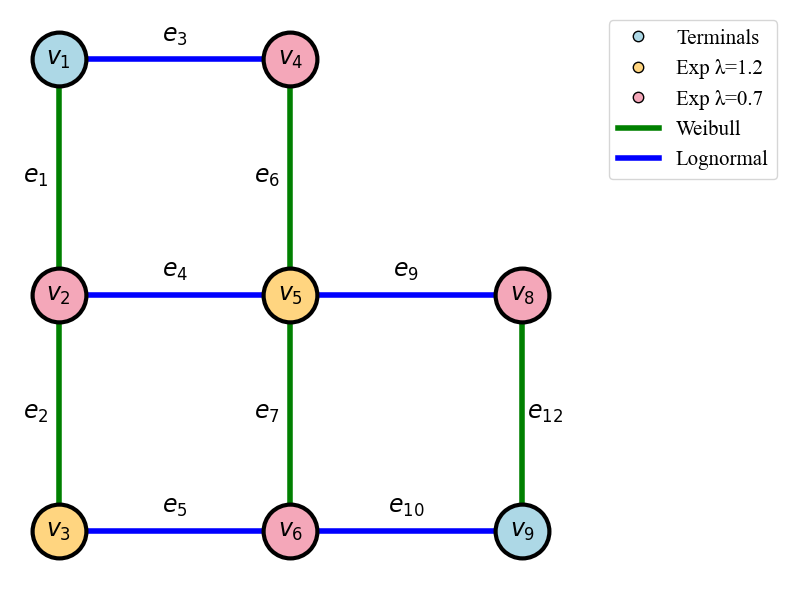

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

G = nx.Graph()

edges_all = [
    (1, 2),  # e1
    (2, 3),  # e2
    (1, 4),  # e3
    (2, 5),  # e4
    (3, 6),  # e5
    (4, 5),  # e6
    (5, 6),  # e7
    (4, 7),  # e8 
    (5, 8),  # e9
    (6, 9),  # e10
    (7, 8),  # e11 
    (8, 9)   # e12
]

edges = [(1, 2), (2, 3), (1, 4), (2, 5), (3, 6), (4, 5),
         (5, 6), (5, 8), (6, 9), (8, 9)]
G.add_edges_from(edges)

Terminals = [1, 9]                
Exp_lambda12 = [3, 5]            
Exp_lambda08 = [2, 4, 6, 8]       

weibull_edges = [1, 2, 6, 7, 11, 12]
lognorm_edges = [3, 4, 5, 8, 9, 10]

for i, edge in enumerate(edges_all, start=1):
    if not G.has_edge(*edge):
        continue
    if i in weibull_edges:
        G[edge[0]][edge[1]]['type'] = 'Weibull'
    elif i in lognorm_edges:
        G[edge[0]][edge[1]]['type'] = 'Lognormal'

fixed_pos = {
    1: (0, 0), 2: (0, -1), 3: (0, -2),
    4: (1, 0), 5: (1, -1), 6: (1, -2),
    8: (2, -1), 9: (2, -2)
}

edge_label_pos = {
    (1, 2): (-0.1, -0.5),
    (2, 3): (-0.1, -1.5),
    (1, 4): (0.5, 0.1),
    (2, 5): (0.5, -0.9),
    (3, 6): (0.5, -1.9),
    (4, 5): (0.9, -0.5),
    (5, 6): (0.9, -1.5),
    (4, 7): (1.5, 0.1),   # e8
    (5, 8): (1.5, -0.9),
    (6, 9): (1.5, -1.9),
    (7, 8): (2.1, -0.5),  # e11
    (8, 9): (2.1, -1.5),
}

plt.figure(figsize=(8, 6))
plt.axis('off')

a = 1500
nx.draw_networkx_nodes(G, fixed_pos, nodelist=Terminals,
                       node_color="lightblue", node_size=a,
                       edgecolors="black", linewidths=3, label="Terminals")
nx.draw_networkx_nodes(G, fixed_pos, nodelist=Exp_lambda12,
                       node_color="#FFD580", node_size=a,
                       edgecolors="black", linewidths=3, label="Exp λ=1.2")
nx.draw_networkx_nodes(G, fixed_pos, nodelist=Exp_lambda08,
                       node_color="#F4A7B9", node_size=a,
                       edgecolors="black", linewidths=3, label="Exp λ=0.7")

edge_colors = {'Weibull': 'green', 'Lognormal': 'blue'}
for etype, color in edge_colors.items():
    selected_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get('type') == etype]
    nx.draw_networkx_edges(G, fixed_pos, edgelist=selected_edges,
                           edge_color=color, width=4)

node_labels = {node: f'${{v_{{{node}}}}}$' for node in G.nodes()}
nx.draw_networkx_labels(G, fixed_pos, labels=node_labels,
                        font_size=17, font_weight='bold', font_family='serif')

for i, (u, v) in enumerate(edges_all, start=1):
    if not G.has_edge(u, v):
        continue  
    label = f'$e_{{{i}}}$'
    x, y = edge_label_pos[(u, v)] if (u, v) in edge_label_pos else edge_label_pos[(v, u)]
    plt.text(x, y, label, fontsize=17, color='black',
             ha='center', va='center')

handles = [
    plt.Line2D([0], [0], marker='o', color='w', label='Terminals',
               markerfacecolor='lightblue', markersize=15, markeredgecolor='black'),
    plt.Line2D([0], [0], marker='o', color='w', label='Exp λ=1.2',
               markerfacecolor='#FFD580', markersize=15, markeredgecolor='black'),
    plt.Line2D([0], [0], marker='o', color='w', label='Exp λ=0.7',
               markerfacecolor='#F4A7B9', markersize=15, markeredgecolor='black'),
    plt.Line2D([0], [0], color='green', lw=4, label='Weibull'),
    plt.Line2D([0], [0], color='blue', lw=4, label='Lognormal')
]

plt.legend(handles=handles, scatterpoints=1, markerscale=0.5,
           fontsize='large', bbox_to_anchor=(1.05, 1), loc='upper left',
           prop={'family': 'Times New Roman', 'size':15})

plt.tight_layout()
plt.savefig('1016mixed variant network.png', bbox_inches='tight')
plt.show()

